
# Demonstration of Tsallis state entropy


In [1]:

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility of the visual jitter.
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Output folder relative to the notebook location.
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Spatial grid. The demonstration uses a 5 x 5 grid only for visual clarity.
GRID_SIZE = 5
N_GRID_STATES = GRID_SIZE * GRID_SIZE

# For the pedagogical figure we use empirical occupancies without additive smoothing.
# Set SMOOTHING_LAMBDA = 0.5 if you want to use the same additive smoothing convention
# as in the full feature-extraction pipeline; the visual logic remains the same, but
# the printed entropy values will change because empty cells receive non-zero mass.
SMOOTHING_LAMBDA = 0.0

# Visual jitter inside each occupied grid cell. This affects only plotting, not entropy values.
JITTER = 0.16


In [2]:

def shannon_entropy_from_counts(counts, n_states=N_GRID_STATES, smoothing=0.0):
    """Compute Shannon entropy from grid-state counts using natural logarithms."""
    c = np.zeros(n_states, dtype=float)
    c[:len(counts)] = np.asarray(counts, dtype=float)
    p = (c + smoothing) / (c.sum() + n_states * smoothing)
    p = p[p > 0]
    return float(-np.sum(p * np.log(p)))


def tsallis_entropy_from_counts(counts, q, n_states=N_GRID_STATES, smoothing=0.0):
    """Compute Tsallis entropy from grid-state counts."""
    if q <= 0:
        raise ValueError("q must be positive")
    if abs(q - 1.0) < 1e-12:
        return shannon_entropy_from_counts(counts, n_states=n_states, smoothing=smoothing)

    c = np.zeros(n_states, dtype=float)
    c[:len(counts)] = np.asarray(counts, dtype=float)
    p = (c + smoothing) / (c.sum() + n_states * smoothing)
    return float((1.0 - np.sum(p ** q)) / (q - 1.0))


def counts_from_cells(cell_counts):
    """Return only the nonzero counts from a dictionary {(x, y): count}."""
    return list(cell_counts.values())


In [3]:

# Coordinates are cell centers on a 5 x 5 grid: (x, y), with x,y in {1,...,5}.
# The order of entries does not matter for state entropy.

# Row A: q < 1 highlights rare states.
# Balanced pattern: 24 fixations across 6 states, each visited 4 times.
A_balanced = {
    (2, 3): 4, (3, 3): 4, (4, 3): 4,
    (2, 2): 4, (3, 2): 4, (4, 2): 4,
}

# Pattern with rare states: 24 fixations, one dominant state plus several rare states.
A_rare = {
    (3, 3): 9,
    (2, 3): 3, (4, 3): 3, (3, 2): 3,
    (1, 1): 2, (5, 1): 2,
    (1, 5): 1, (5, 5): 1,
}

# Row B: q > 1 downweights rare states.
# Three dominant states: 27 fixations across 3 states, each visited 9 times.
B_dominant = {
    (2, 3): 9, (3, 3): 9, (4, 3): 9,
}

# Same dominant core plus rare excursions: still 27 fixations, but three rare states are added.
B_rare = {
    (2, 3): 8, (3, 3): 8, (4, 3): 8,
    (2, 5): 1, (1, 1): 1, (5, 1): 1,
}

patterns = {
    "A_balanced": A_balanced,
    "A_rare": A_rare,
    "B_dominant": B_dominant,
    "B_rare": B_rare,
}

# Check number of fixations.
for name, cell_counts in patterns.items():
    print(f"{name}: {sum(cell_counts.values())} fixations, {len(cell_counts)} occupied states")


A_balanced: 24 fixations, 6 occupied states
A_rare: 24 fixations, 8 occupied states
B_dominant: 27 fixations, 3 occupied states
B_rare: 27 fixations, 6 occupied states


In [4]:

# Compute metrics used in the annotation boxes.
metrics = []
for name, cell_counts in patterns.items():
    counts = counts_from_cells(cell_counts)
    metrics.append({
        "pattern": name,
        "n_fixations": sum(counts),
        "n_occupied_states": len(counts),
        "shannon_H": shannon_entropy_from_counts(counts, smoothing=SMOOTHING_LAMBDA),
        "tsallis_q_0_5": tsallis_entropy_from_counts(counts, q=0.5, smoothing=SMOOTHING_LAMBDA),
        "tsallis_q_2": tsallis_entropy_from_counts(counts, q=2.0, smoothing=SMOOTHING_LAMBDA),
    })

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(OUTPUT_DIR / "synthetic_tsallis_entropy_metrics.csv", index=False)
metrics_df


,pattern,n_fixations,n_occupied_states,shannon_H,tsallis_q_0_5,tsallis_q_2
0,A_balanced,24,6,1.791759,2.898979,0.833333
1,A_rare,24,8,1.826590,3.317262,0.795139
2,B_dominant,27,3,1.098612,1.464102,0.666667
3,B_rare,27,6,1.447444,2.420687,0.732510


In [5]:

# Color palette: soft green for compact/balanced patterns, purple for patterns with rare states.
COLORS = {
    "left_dark": "#1b5e20",
    "left_mid": "#2e7d32",
    "left_light": "#eef7ef",
    "left_title": "#cae8cf",
    "right_dark": "#4a148c",
    "right_mid": "#6a1b9a",
    "right_light": "#f4effa",
    "right_title": "#dfcdf2",
    "navy": "#0b1f4d",
    "grid": "#c7ccd1",
    "box_fill": "#f8fbff",
    "box_edge": "#0b2a5b",
}


def jitter_points(cell_counts, rng, jitter=JITTER):
    """Generate jittered fixation coordinates inside each occupied grid cell."""
    xs, ys = [], []
    for (x, y), n in cell_counts.items():
        xs.extend(x + rng.uniform(-jitter, jitter, size=n))
        ys.extend(y + rng.uniform(-jitter, jitter, size=n))
    return np.asarray(xs), np.asarray(ys)


def setup_grid_axis(ax, title, theme="left"):
    """Prepare one 5 x 5 occupancy panel."""
    if theme == "left":
        face = COLORS["left_light"]
        title_fc = COLORS["left_title"]
        spine_color = "#83bf8e"
        title_color = COLORS["left_dark"]
    else:
        face = COLORS["right_light"]
        title_fc = COLORS["right_title"]
        spine_color = "#a77bd4"
        title_color = COLORS["right_dark"]

    ax.set_facecolor(face)
    ax.set_xlim(0.5, GRID_SIZE + 0.5)
    ax.set_ylim(0.5, GRID_SIZE + 0.5)
    ax.set_aspect("equal")

    # Light grid lines show the discretization, but no in-cell count labels are used.
    for v in np.arange(0.5, GRID_SIZE + 1.0, 1.0):
        ax.axvline(v, color=COLORS["grid"], lw=0.8, ls="--", zorder=0)
        ax.axhline(v, color=COLORS["grid"], lw=0.8, ls="--", zorder=0)

    ax.set_xticks(range(1, GRID_SIZE + 1))
    ax.set_yticks(range(1, GRID_SIZE + 1))
    ax.tick_params(axis="both", length=0, labelsize=10, colors="#1f2933")
    for spine in ax.spines.values():
        spine.set_color(spine_color)
        spine.set_linewidth(1.2)

    ax.set_title(
        title,
        fontsize=12,
        fontweight="bold",
        color=title_color,
        pad=10,
        bbox=dict(boxstyle="round,pad=0.35,rounding_size=0.8", fc=title_fc, ec="none"),
    )


def plot_occupancy(ax, cell_counts, title, theme, rng):
    """Plot jittered fixation dots for one synthetic pattern."""
    setup_grid_axis(ax, title, theme=theme)
    xs, ys = jitter_points(cell_counts, rng=rng)
    color = COLORS["left_mid"] if theme == "left" else COLORS["right_mid"]
    ax.scatter(
        xs, ys,
        s=23,
        c=color,
        edgecolors="white",
        linewidths=0.35,
        alpha=0.95,
        zorder=3,
    )


def add_metric_box(ax, lines):
    """Add a rounded annotation box spanning a row."""
    ax.axis("off")
    text = "\n".join(lines)
    ax.text(
        0.5, 0.5,
        text,
        ha="center",
        va="center",
        fontsize=11,
        color=COLORS["navy"],
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55,rounding_size=0.25",
            fc=COLORS["box_fill"],
            ec=COLORS["box_edge"],
            lw=1.5,
        ),
    )


Saved:
- outputs\synthetic_tsallis_state_entropy_demo.png
- outputs\synthetic_tsallis_state_entropy_demo.pdf
- outputs\synthetic_tsallis_state_entropy_demo.svg


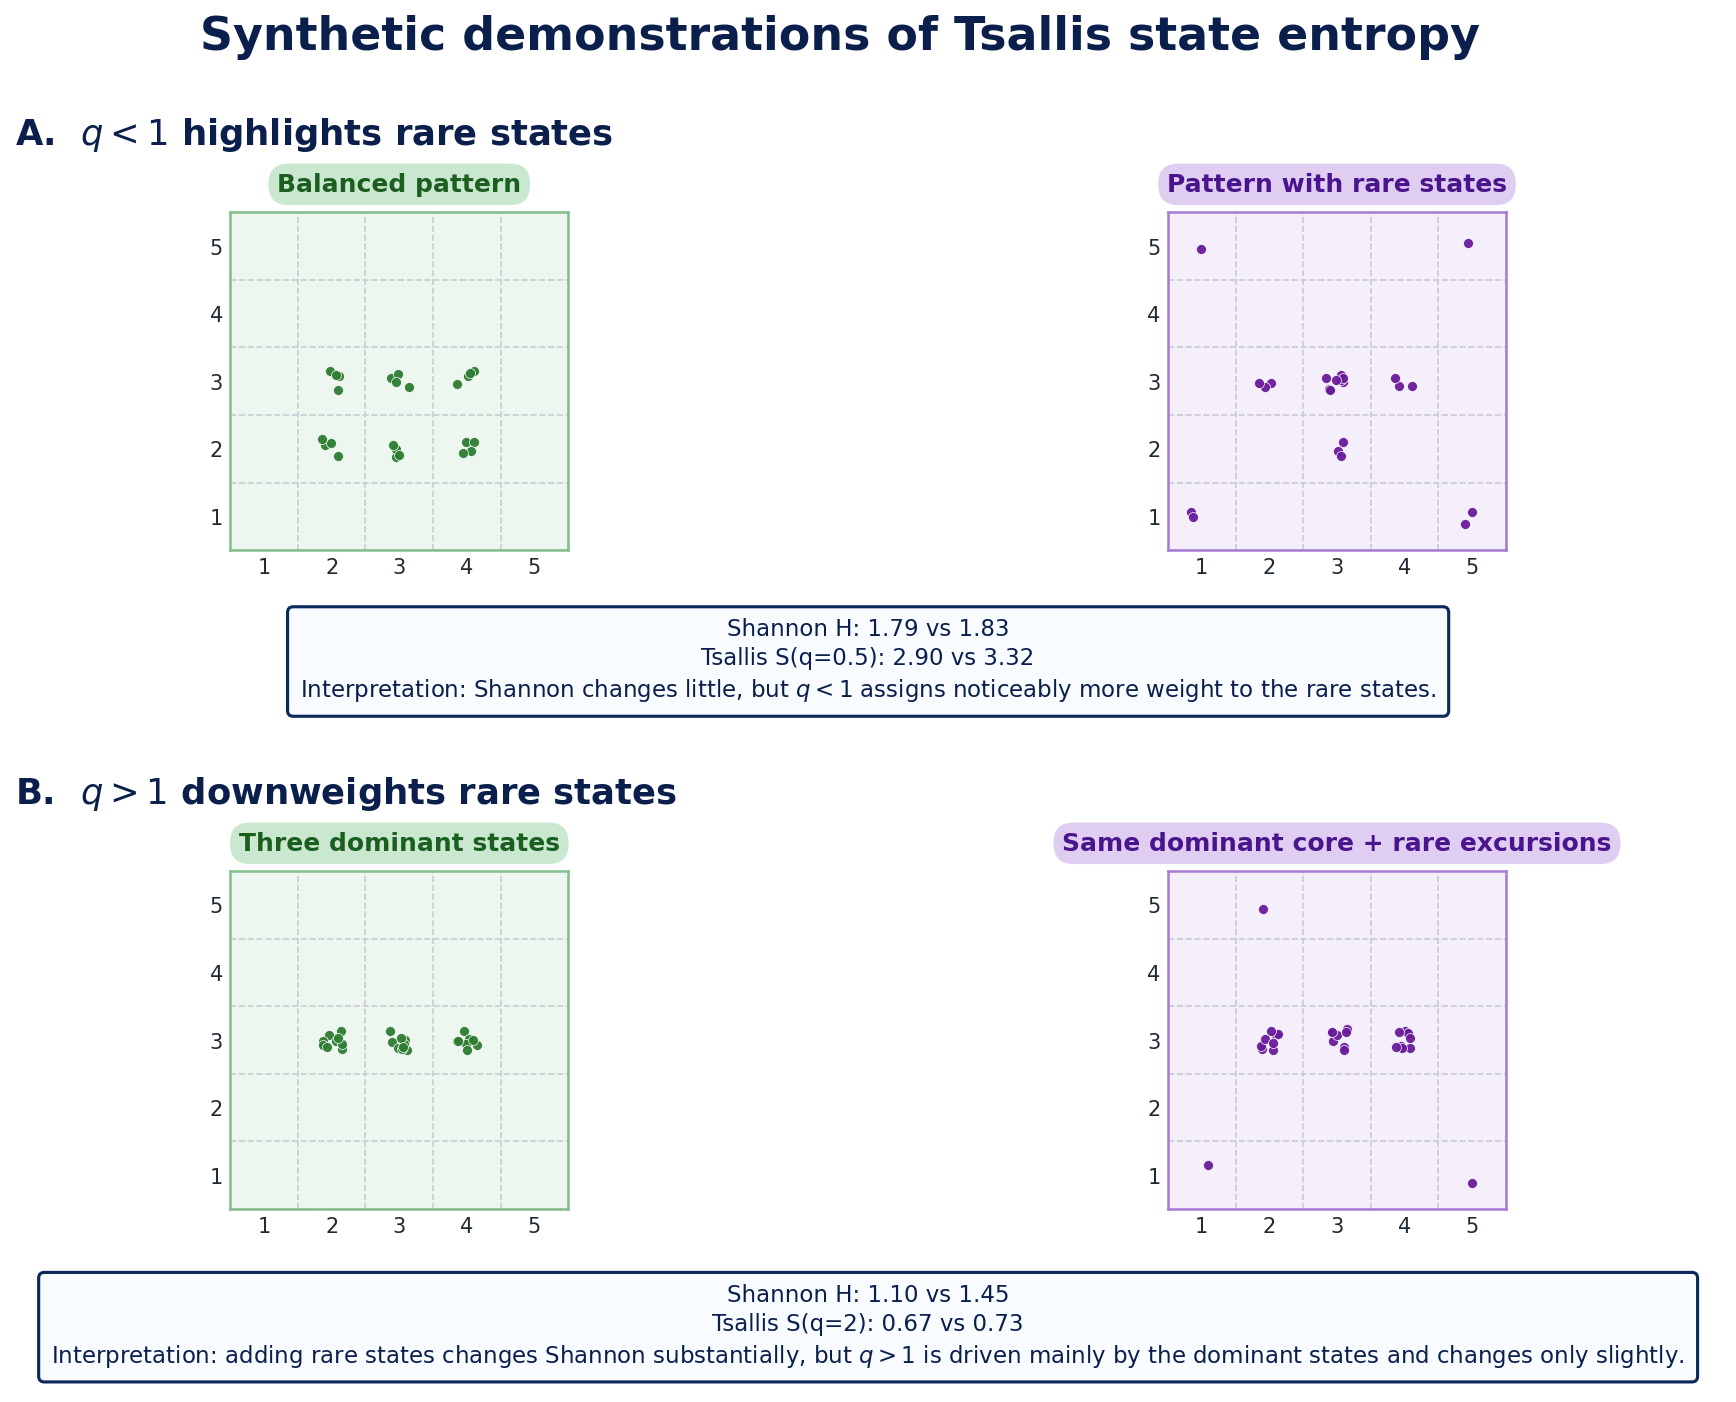

In [6]:

# Extract values for concise labels.
get = metrics_df.set_index("pattern")

A_H_left = get.loc["A_balanced", "shannon_H"]
A_H_right = get.loc["A_rare", "shannon_H"]
A_T_left = get.loc["A_balanced", "tsallis_q_0_5"]
A_T_right = get.loc["A_rare", "tsallis_q_0_5"]

B_H_left = get.loc["B_dominant", "shannon_H"]
B_H_right = get.loc["B_rare", "shannon_H"]
B_T_left = get.loc["B_dominant", "tsallis_q_2"]
B_T_right = get.loc["B_rare", "tsallis_q_2"]

# Recreate the RNG before plotting so the visual jitter is stable if cells are rerun.
rng = np.random.default_rng(RANDOM_SEED)

fig = plt.figure(figsize=(12.5, 10.0), dpi=150)
gs = fig.add_gridspec(
    nrows=6,
    ncols=2,
    height_ratios=[0.13, 1.0, 0.32, 0.13, 1.0, 0.36],
    hspace=0.34,
    wspace=0.22,
    top=0.91,
    bottom=0.06,
    left=0.06,
    right=0.97,
)

ax_label_a = fig.add_subplot(gs[0, :])
ax_a1 = fig.add_subplot(gs[1, 0])
ax_a2 = fig.add_subplot(gs[1, 1])
ax_box_a = fig.add_subplot(gs[2, :])
ax_label_b = fig.add_subplot(gs[3, :])
ax_b1 = fig.add_subplot(gs[4, 0])
ax_b2 = fig.add_subplot(gs[4, 1])
ax_box_b = fig.add_subplot(gs[5, :])

for ax in (ax_label_a, ax_label_b):
    ax.axis("off")

ax_label_a.text(0.0, 0.48, r"A.  $q < 1$ highlights rare states", fontsize=17, fontweight="bold", color=COLORS["navy"], va="center")
ax_label_b.text(0.0, 0.48, r"B.  $q > 1$ downweights rare states", fontsize=17, fontweight="bold", color=COLORS["navy"], va="center")

plot_occupancy(ax_a1, A_balanced, "Balanced pattern", theme="left", rng=rng)
plot_occupancy(ax_a2, A_rare, "Pattern with rare states", theme="right", rng=rng)
plot_occupancy(ax_b1, B_dominant, "Three dominant states", theme="left", rng=rng)
plot_occupancy(ax_b2, B_rare, "Same dominant core + rare excursions", theme="right", rng=rng)

fig.suptitle(
    "Synthetic demonstrations of Tsallis state entropy",
    fontsize=22,
    fontweight="bold",
    color=COLORS["navy"],
    y=0.975,
)

add_metric_box(ax_box_a, [
    f"Shannon H: {A_H_left:.2f} vs {A_H_right:.2f}",
    f"Tsallis S(q=0.5): {A_T_left:.2f} vs {A_T_right:.2f}",
    r"Interpretation: Shannon changes little, but $q < 1$ assigns noticeably more weight to the rare states.",
])

add_metric_box(ax_box_b, [
    f"Shannon H: {B_H_left:.2f} vs {B_H_right:.2f}",
    f"Tsallis S(q=2): {B_T_left:.2f} vs {B_T_right:.2f}",
    r"Interpretation: adding rare states changes Shannon substantially, but $q > 1$ is driven mainly by the dominant states and changes only slightly.",
])

# Save figure in common formats.
png_path = OUTPUT_DIR / "synthetic_tsallis_state_entropy_demo.png"
pdf_path = OUTPUT_DIR / "synthetic_tsallis_state_entropy_demo.pdf"
svg_path = OUTPUT_DIR / "synthetic_tsallis_state_entropy_demo.svg"

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(svg_path, bbox_inches="tight")

print(f"Saved:\n- {png_path}\n- {pdf_path}\n- {svg_path}")
plt.show()



# Demonstration of Free energy from stepth length

Pattern A mean / median / skew / kurtosis: 1.359 1.5 0.8362 0.0389
Pattern B mean / median / skew / kurtosis: 1.3623 1.5 0.8417 -0.0254
Free-energy gap at beta=0.5: 0.2268
Free-energy gap at beta=1.0: 0.3766
Free-energy gap at beta=2.0: 0.5495
Free-energy gap at beta=3.0: 0.6308
Free-energy gap at beta=4.0: 0.6683


C:\Users\LEGION\AppData\Local\Temp\ipykernel_22952\712391151.py:373: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


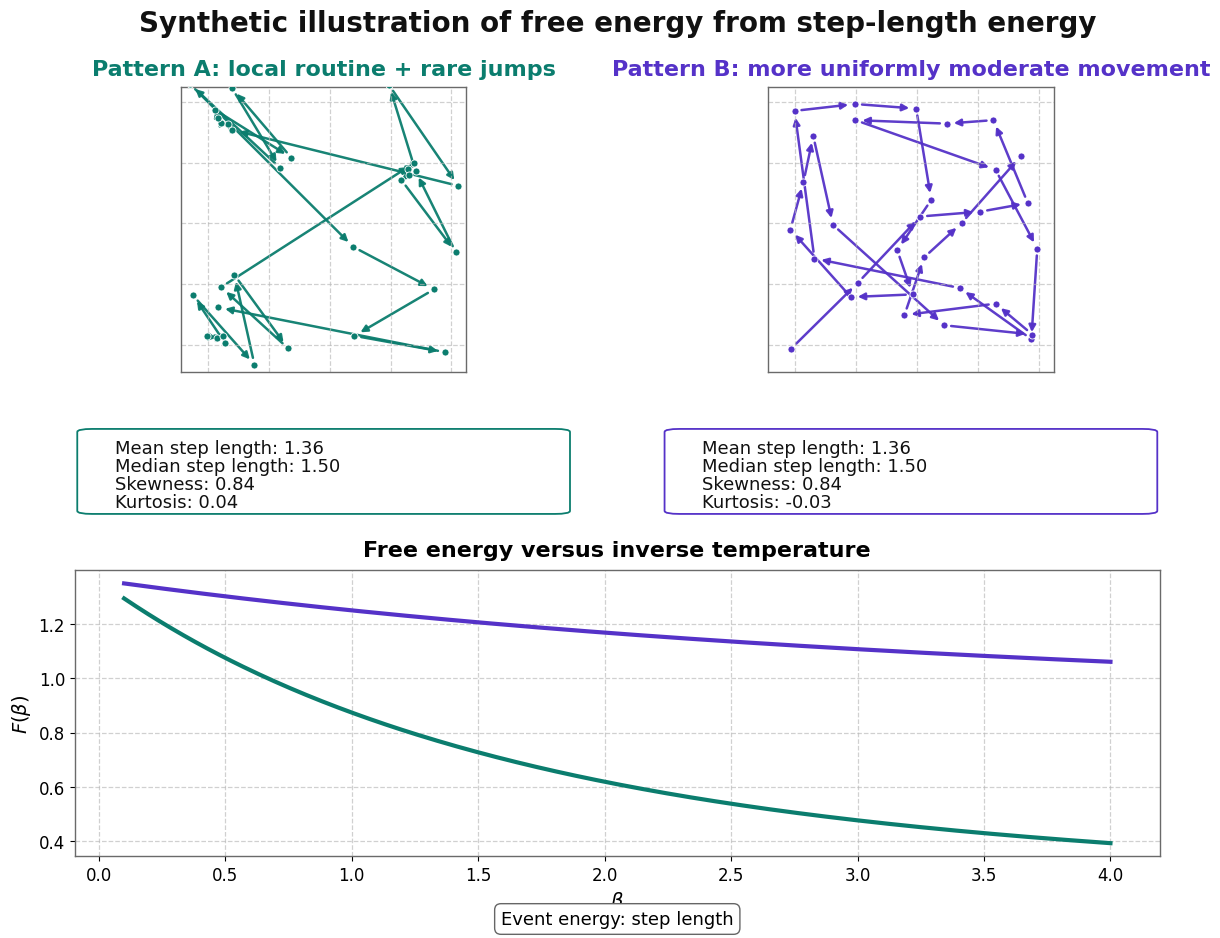

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from pathlib import Path
from scipy.stats import skew, kurtosis

# ============================================================
# Synthetic illustration:
# simple step-length statistics are very similar,
# including skewness and kurtosis,
# but free energy separates the scanpaths increasingly with beta.
# ============================================================

OUTDIR = Path("free_energy_step_length_similarity_natural_outputs")
OUTDIR.mkdir(exist_ok=True)

# ----------------------------
# Style
# ----------------------------
GREEN = "#0B7D6E"
PURPLE = "#5532C8"
GRID = "#B8B8B8"
TEXT = "#111111"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ----------------------------
# Core quantities
# ----------------------------
def step_lengths(points):
    points = np.asarray(points, dtype=float)
    return np.linalg.norm(np.diff(points, axis=0), axis=1)

def normalized_free_energy_q1(energies, beta):
    """
    Event-count-normalized q=1 free energy:
        F_norm(beta) = -(1/beta) log mean_k exp(-beta E_k)
    """
    energies = np.asarray(energies, dtype=float)
    return -(1.0 / beta) * np.log(np.mean(np.exp(-beta * energies)))

# ----------------------------
# Energy sequences
# ----------------------------
# These were chosen so that mean / median / skewness / kurtosis remain close,
# while free energy still separates the two patterns clearly.
E_A = np.array([0.12] * 10 + [0.95] * 1 + [1.50] * 13 + [1.98] * 2 + [3.79] * 4)
E_B = np.array([0.79] * 7  + [1.02] * 6 + [1.50] * 13 + [2.43] * 4)

mean_A, mean_B = E_A.mean(), E_B.mean()
median_A, median_B = np.median(E_A), np.median(E_B)
skew_A, skew_B = skew(E_A), skew(E_B)
kurt_A, kurt_B = kurtosis(E_A), kurtosis(E_B)

# ----------------------------
# Synthetic scanpaths
# ----------------------------
def make_pattern_a_natural(lengths, seed=41, bounds=(0.65, 5.35)):
    """
    Pattern A:
    many short local moves, some medium moves, a few long relocations.
    Constructed to look less artificial than square loops.
    """
    rng = np.random.default_rng(seed)
    low, high = bounds

    # Same multiset as E_A, but arranged to tell the visual story:
    # local routine -> long relocation -> local routine -> ...
    seq = np.array(
        [0.12] * 3 + [0.95] * 1 + [1.50] * 4 + [3.79] * 1 +
        [0.12] * 3 + [1.50] * 3 + [1.98] * 1 + [3.79] * 1 +
        [0.12] * 4 + [1.50] * 3 + [1.98] * 1 + [3.79] * 1 +
        [1.50] * 3 + [3.79] * 1,
        dtype=float
    )
    assert np.allclose(np.sort(seq), np.sort(lengths))

    centers = [
        np.array([1.15, 1.25]),
        np.array([4.60, 4.10]),
        np.array([1.35, 4.55]),
        np.array([4.70, 1.25]),
        np.array([1.30, 1.20]),
    ]

    p = np.array([1.00, 1.15], dtype=float)
    points = [p.copy()]
    center_idx = 0
    last_angle = rng.uniform(0, 2 * np.pi)

    def inside(x):
        return low <= x[0] <= high and low <= x[1] <= high

    def not_axis_aligned(angle):
        c, s = abs(np.cos(angle)), abs(np.sin(angle))
        return min(c, s) > 0.18 and max(c, s) < 0.98

    for L in seq:
        if L >= 3.5:
            target_center = centers[center_idx + 1]
            base = np.arctan2(target_center[1] - p[1], target_center[0] - p[0])

            candidates = []
            trial_angles = np.concatenate([
                base + rng.normal(0.0, 0.28, size=1000),
                rng.uniform(0, 2 * np.pi, size=1000)
            ])

            for angle in trial_angles:
                newp = p + L * np.array([np.cos(angle), np.sin(angle)])
                if inside(newp) and not_axis_aligned(angle):
                    margin = min(newp[0] - low, high - newp[0], newp[1] - low, high - newp[1])
                    score = np.linalg.norm(newp - target_center) - 0.10 * margin
                    candidates.append((score, angle, newp))

            if not candidates:
                for angle in rng.uniform(0, 2 * np.pi, size=5000):
                    newp = p + L * np.array([np.cos(angle), np.sin(angle)])
                    if inside(newp):
                        candidates.append((0.0, angle, newp))
                        break

            candidates.sort(key=lambda z: z[0])
            _, angle, p = candidates[0]
            points.append(p.copy())
            center_idx += 1
            last_angle = angle
            continue

        center = centers[center_idx]

        for _ in range(4000):
            if L < 0.3:
                angle = last_angle + rng.normal(0.0, 1.0)
            else:
                to_center = np.arctan2(center[1] - p[1], center[0] - p[0])
                orbit = to_center + rng.choice([-1, 1]) * rng.uniform(0.65, 1.55)
                angle = 0.65 * orbit + 0.35 * (last_angle + rng.normal(0.0, 0.75))

            if not not_axis_aligned(angle):
                continue

            newp = p + L * np.array([np.cos(angle), np.sin(angle)])
            if not inside(newp):
                continue

            if np.linalg.norm(newp - center) > (1.45 if L < 0.3 else 1.95):
                continue

            if len(points) > 2 and np.linalg.norm(newp - points[-2]) < 0.10:
                continue

            p = newp
            points.append(p.copy())
            last_angle = angle
            break
        else:
            raise RuntimeError("Could not place Pattern A point.")

    return np.asarray(points), seq

def generate_pattern_b(lengths, seed=18, bounds=(0.75, 5.05), start=(0.95, 0.95)):
    """
    Pattern B:
    more uniformly moderate movement.
    """
    rng = np.random.default_rng(seed)
    low, high = bounds
    p = np.array(start, dtype=float)
    points = [p.copy()]
    last_angle = None

    lengths = np.array(lengths, dtype=float).copy()
    rng.shuffle(lengths)

    for L in lengths:
        accepted = False

        for attempt in range(3000):
            if last_angle is None or attempt > 700:
                angle = rng.uniform(0, 2 * np.pi)
            else:
                angle = last_angle + rng.normal(0.0, 0.95)

            new = p + L * np.array([np.cos(angle), np.sin(angle)])

            if low <= new[0] <= high and low <= new[1] <= high:
                if len(points) > 2 and np.linalg.norm(new - points[-2]) < 0.35:
                    continue
                accepted = True
                break

        if not accepted:
            center = np.array([(low + high) / 2, (low + high) / 2])
            base = np.arctan2(center[1] - p[1], center[0] - p[0])
            for angle in np.linspace(base - np.pi, base + np.pi, 720):
                new = p + L * np.array([np.cos(angle), np.sin(angle)])
                if low <= new[0] <= high and low <= new[1] <= high:
                    accepted = True
                    break

        if not accepted:
            raise RuntimeError("Could not place Pattern B point.")

        points.append(new.copy())
        p = new
        last_angle = angle

    return np.asarray(points), lengths

P_A, E_A_ordered = make_pattern_a_natural(E_A)
P_B, E_B_ordered = generate_pattern_b(E_B)

# Sanity checks
assert len(E_A) == len(E_B) == 30
assert np.isclose(np.median(E_A), np.median(E_B))

# ----------------------------
# Plot helpers
# ----------------------------
def draw_scanpath(ax, points, color, title):
    ax.set_title(title, color=color, fontsize=16, fontweight="bold", pad=8)
    ax.set_xlim(0.55, 5.25)
    ax.set_ylim(0.55, 5.25)
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(1, 6))
    ax.set_yticks(np.arange(1, 6))
    ax.grid(True, linestyle="--", color=GRID, alpha=0.65, linewidth=0.9)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    for spine in ax.spines.values():
        spine.set_color("#6A6A6A")
        spine.set_linewidth(1.0)

    rng = np.random.default_rng(123)
    jitter = rng.normal(0, 0.018, size=points.shape)
    pts_plot = points + jitter

    for i in range(len(pts_plot) - 1):
        x1, y1 = pts_plot[i]
        x2, y2 = pts_plot[i + 1]
        arrow = FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle='-|>',
            mutation_scale=10,
            linewidth=1.8,
            color=color,
            alpha=0.95,
            shrinkA=5,
            shrinkB=5
        )
        ax.add_patch(arrow)

    ax.scatter(
        pts_plot[:, 0], pts_plot[:, 1],
        s=26, color=color, edgecolors="white", linewidths=0.6, zorder=3
    )

def stats_box(ax, color, mean_v, median_v, skew_v, kurt_v):
    ax.axis("off")
    patch = FancyBboxPatch(
        (0.03, 0.10), 0.94, 0.80,
        boxstyle="round,pad=0.025,rounding_size=0.03",
        linewidth=1.3,
        edgecolor=color,
        facecolor="white",
        transform=ax.transAxes
    )
    ax.add_patch(patch)

    lines = [
        f"Mean step length: {mean_v:.2f}",
        f"Median step length: {median_v:.2f}",
        f"Skewness: {skew_v:.2f}",
        f"Kurtosis: {kurt_v:.2f}",
    ]

    y0 = 0.73
    for i, line in enumerate(lines):
        ax.text(
            0.08, y0 - i * 0.18, line,
            fontsize=13, color=TEXT,
            ha="left", va="center",
            transform=ax.transAxes
        )

# ----------------------------
# Free energy
# ----------------------------
betas = np.linspace(0.1, 4.0, 250)
F_A = np.array([normalized_free_energy_q1(E_A, b) for b in betas])
F_B = np.array([normalized_free_energy_q1(E_B, b) for b in betas])

# ----------------------------
# Figure
# ----------------------------
fig = plt.figure(figsize=(14, 11), constrained_layout=False)
gs = fig.add_gridspec(
    nrows=4, ncols=2,
    height_ratios=[0.10, 1.00, 0.35, 1.00],
    hspace=0.28, wspace=0.18
)

# Title
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis("off")
ax_title.text(
    0.5, 0.5,
    "Synthetic illustration of free energy from step-length energy",
    ha="center", va="center",
    fontsize=20, fontweight="bold", color=TEXT
)

# Scanpaths
axA = fig.add_subplot(gs[1, 0])
axB = fig.add_subplot(gs[1, 1])
draw_scanpath(axA, P_A, GREEN, "Pattern A: local routine + rare jumps")
draw_scanpath(axB, P_B, PURPLE, "Pattern B: more uniformly moderate movement")

# Stat boxes
axA_stats = fig.add_subplot(gs[2, 0])
axB_stats = fig.add_subplot(gs[2, 1])
stats_box(axA_stats, GREEN, mean_A, median_A, skew_A, kurt_A)
stats_box(axB_stats, PURPLE, mean_B, median_B, skew_B, kurt_B)

# Free-energy plot
axF = fig.add_subplot(gs[3, :])
axF.plot(betas, F_A, color=GREEN, linewidth=3.0)
axF.plot(betas, F_B, color=PURPLE, linewidth=3.0)

axF.set_title("Free energy versus inverse temperature", fontsize=16, fontweight="bold", pad=10)
axF.set_xlabel(r"$\beta$", fontsize=14)
axF.set_ylabel(r"$F(\beta)$", fontsize=14)
axF.grid(True, linestyle="--", color=GRID, alpha=0.65, linewidth=0.9)

for spine in axF.spines.values():
    spine.set_color("#6A6A6A")
    spine.set_linewidth(1.0)

# Small bottom label, no legend and no explanation
axF.text(
    0.5, -0.22,
    "Event energy: step length",
    ha="center", va="center",
    transform=axF.transAxes,
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#666666")
)

# ----------------------------
# Console summary
# ----------------------------
print("Pattern A mean / median / skew / kurtosis:",
      round(mean_A, 4), round(median_A, 4), round(skew_A, 4), round(kurt_A, 4))
print("Pattern B mean / median / skew / kurtosis:",
      round(mean_B, 4), round(median_B, 4), round(skew_B, 4), round(kurt_B, 4))

for b in [0.5, 1.0, 2.0, 3.0, 4.0]:
    gap = normalized_free_energy_q1(E_B, b) - normalized_free_energy_q1(E_A, b)
    print(f"Free-energy gap at beta={b}: {gap:.4f}")

# ----------------------------
# Save
# ----------------------------
plt.tight_layout()
plt.savefig(OUTDIR / "synthetic_free_energy_step_length_similarity_natural.png", dpi=300, bbox_inches="tight")
plt.savefig(OUTDIR / "synthetic_free_energy_step_length_similarity_natural.pdf", bbox_inches="tight")
plt.savefig(OUTDIR / "synthetic_free_energy_step_length_similarity_natural.svg", bbox_inches="tight")
plt.show()